In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time

headers = {
    "User-Agent": "Mozilla/5.0"
}

base = "https://www.myprotein.tw"

########################################
# 1 抓商品列表
########################################

products = []

for page in range(1,6):

    url = f"https://www.myprotein.tw/c/nutrition/protein/?page={page}"

    r = requests.get(url, headers=headers)
    r.encoding = "utf-8"

    soup = BeautifulSoup(r.text, "html.parser")

    for a in soup.select('a[href*="/p/"]'):

        name = a.get_text(strip=True)
        link = a.get("href")

        if not name:
            continue

        # 避免抓到 rating text
        if "out of 5 stars" in name.lower():
            continue

        if link:

            if not link.startswith("http"):
                link = base + link

            products.append({
                "product_name": name,
                "url": link
            })

df = pd.DataFrame(products)

df = df.drop_duplicates().reset_index(drop=True)

print("products found:", len(df))


########################################
# 2 抓商品頁資料
########################################

prices = []
ratings = []
reviews = []

for link in df["url"]:

    try:

        r = requests.get(link, headers=headers, timeout=10)
        r.encoding = "utf-8"

        soup = BeautifulSoup(r.text, "html.parser")

        price = None
        rating = None
        review = None

        scripts = soup.find_all("script")

        for s in scripts:

            text = s.text

            # rating
            rating_match = re.search(r'"ratingValue":\s*([0-9.]+)', text)

            if rating_match:
                rating = float(rating_match.group(1))

            # review count
            review_match = re.search(r'"reviewCount":\s*([0-9]+)', text)

            if review_match:
                review = int(review_match.group(1))

            # price
            price_match = re.search(r'"price":\s*"?([0-9.]+)"?', text)

            if price_match:
                price = float(price_match.group(1))

        prices.append(price)
        ratings.append(rating)
        reviews.append(review)

        time.sleep(0.5)

    except:

        prices.append(None)
        ratings.append(None)
        reviews.append(None)

########################################
# 3 加回 dataframe
########################################

df["price"] = prices
df["rating"] = ratings
df["reviews"] = reviews

df.head(28)

products found: 28


,product_name,url,price,rating,reviews
0,Impact 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,4100.0,4.77,1216.0
1,Impact 分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,7260.0,4.74,182.0
2,透明分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/cl...,2350.0,4.80,82.0
3,增肌配方粉,https://www.myprotein.tw/p/sports-nutrition/im...,2760.0,4.65,37.0
4,Essential 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/es...,1850.0,NaN,NaN
5,透明高蛋白膠原蛋白粉,https://www.myprotein.tw/p/sports-nutrition/cl...,2260.0,4.80,5.0
6,透明乳清蛋白 Splash 夏日清爽版,https://www.myprotein.tw/p/sports-nutrition/cl...,1800.0,NaN,NaN
7,大豆分離蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,830.0,4.67,39.0
8,Impact 窈窕乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,2380.0,4.79,52.0
9,純素高蛋白營養配方粉,https://www.myprotein.tw/p/sports-nutrition/im...,1250.0,4.63,8.0


In [2]:
df.head(28)

,product_name,url,price,rating,reviews
0,Impact 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,4100.0,4.77,1216.0
1,Impact 分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,7260.0,4.74,182.0
2,透明分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/cl...,2350.0,4.80,82.0
3,增肌配方粉,https://www.myprotein.tw/p/sports-nutrition/im...,2760.0,4.65,37.0
4,Essential 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/es...,1850.0,NaN,NaN
5,透明高蛋白膠原蛋白粉,https://www.myprotein.tw/p/sports-nutrition/cl...,2260.0,4.80,5.0
6,透明乳清蛋白 Splash 夏日清爽版,https://www.myprotein.tw/p/sports-nutrition/cl...,1800.0,NaN,NaN
7,大豆分離蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,830.0,4.67,39.0
8,Impact 窈窕乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,2380.0,4.79,52.0
9,純素高蛋白營養配方粉,https://www.myprotein.tw/p/sports-nutrition/im...,1250.0,4.63,8.0


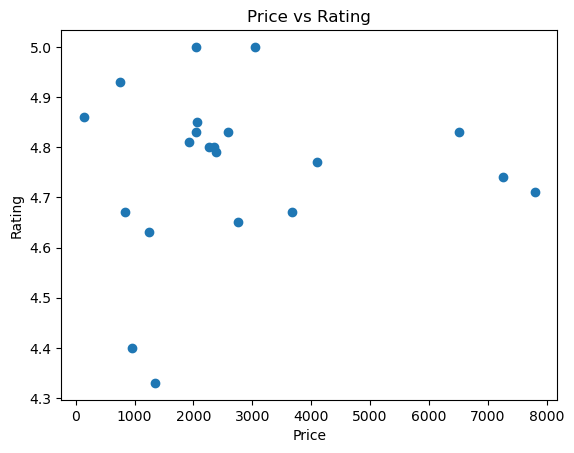

In [3]:
import matplotlib.pyplot as plt

plt.scatter(df["price"], df["rating"])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

###價格vs評分

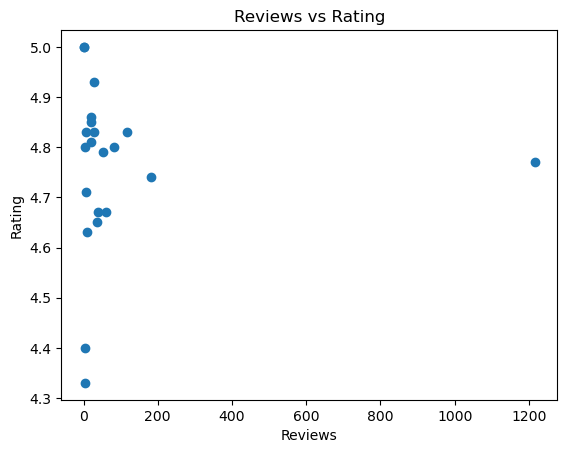

In [4]:
plt.scatter(df["reviews"], df["rating"])
plt.xlabel("Reviews")
plt.ylabel("Rating")
plt.title("Reviews vs Rating")
plt.show()

In [5]:
df["value_score"] = df["rating"] * df["reviews"] / df["price"]

df.sort_values("value_score", ascending=False)

,product_name,url,price,rating,reviews,value_score
0,Impact 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,4100.0,4.77,1216.0,1.414712
12,透明分離乳清蛋白粉（單包）,https://www.myprotein.tw/p/sports-nutrition/cl...,140.0,4.86,21.0,0.729000
21,英式奶茶口味 IMPACT 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,2050.0,4.83,118.0,0.278020
7,大豆分離蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,830.0,4.67,39.0,0.219434
27,黑糖珍奶口味 Impact 乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,760.0,4.93,28.0,0.181632
2,透明分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/cl...,2350.0,4.80,82.0,0.167489
1,Impact 分離乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,7260.0,4.74,182.0,0.118826
8,Impact 窈窕乳清蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,2380.0,4.79,52.0,0.104655
13,豌豆分離蛋白粉,https://www.myprotein.tw/p/sports-nutrition/im...,3680.0,4.67,61.0,0.077410
3,增肌配方粉,https://www.myprotein.tw/p/sports-nutrition/im...,2760.0,4.65,37.0,0.062337


In [6]:
df["price"].describe()

count      28.000000
mean     2492.142857
std      1904.124874
min       140.000000
25%      1325.000000
50%      2160.000000
75%      2632.500000
max      7800.000000
Name: price, dtype: float64

In [16]:
df.to_csv("protein_data_utf8.csv", index=False, encoding="utf-8-sig")